In [1]:
print("all okay")

all okay


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
# print("")

In [4]:
from langchain_openai import ChatOpenAI

In [5]:
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

In [6]:
chat_llm = ChatGroq(model = "llama-3.3-70b-versatile")

In [7]:
chat_llm.invoke("Hello, how are you?").content

"Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you. How can I help you today?"

In [8]:
from typing_extensions import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [9]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [10]:
{
    "messages": [HumanMessage(content="Hi, this is Anees. Say Hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Anees. Say Hello in detail.', additional_kwargs={}, response_metadata={})]}

In [11]:
["Hye"]

['Hye']

In [12]:
["Hye", "How are you?"]

['Hye', 'How are you?']

In [13]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI responses."""
    response = chat_llm.invoke(state["messages"]) # AI message
    return {
        "messages": [response]
    }


In [14]:
def token_counter(state: GraphState) -> dict:
    """count tokens (simple word count) in the last AI message"""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [15]:
from langgraph.graph import StateGraph

In [16]:
builder = StateGraph(GraphState)

In [17]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [18]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [19]:
app = builder.compile()

In [20]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [21]:
from IPython.display import Image, display

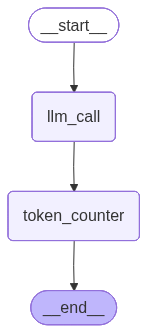

In [22]:
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Anees. Say Hello in detail.")]
})

In [24]:
result

{'messages': [HumanMessage(content='Hi, this is Anees. Say Hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Anees, it's a pleasure to meet you. I hope this greeting finds you in the best of spirits and having a fantastic day. I'm more than happy to have the opportunity to connect with you and engage in a conversation that's both meaningful and enjoyable.\n\nAs we begin our interaction, I want to assure you that I'm here to listen, provide information, and offer assistance in any way I can. Please feel free to share your thoughts, ask questions, or discuss topics that interest you, and I'll do my best to respond in a helpful and informative manner.\n\nIf you're looking for a specific type of conversation or have a particular topic in mind, don't hesitate to let me know. I'm all ears and ready to adapt to your needs. Whether it's a casual chat, a discussion on a specific subject, or even a fun activity, I'm excited to explore new ideas and learn 

In [25]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Anees. Say Hello in detail.
AIMessage : Hello Anees, it's a pleasure to meet you. I hope this greeting finds you in the best of spirits and having a fantastic day. I'm more than happy to have the opportunity to connect with you and engage in a conversation that's both meaningful and enjoyable.

As we begin our interaction, I want to assure you that I'm here to listen, provide information, and offer assistance in any way I can. Please feel free to share your thoughts, ask questions, or discuss topics that interest you, and I'll do my best to respond in a helpful and informative manner.

If you're looking for a specific type of conversation or have a particular topic in mind, don't hesitate to let me know. I'm all ears and ready to adapt to your needs. Whether it's a casual chat, a discussion on a specific subject, or even a fun activity, I'm excited to explore new ideas and learn from your perspective.

So, Anees, what's on your mind today? What brings you her

In [26]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024D5069F5D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024D50946310>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [27]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [28]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [29]:
wiki_runner = WikipediaQueryRun(api_wrapper=api_wrapper)

In [30]:
wiki_runner.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data.\nThese models learn the underlying patterns and structures of their training data and use them to generate new data\nin response to input, which often takes the form of natural language prompts.\nThe generated material is often cal'

In [31]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [32]:
print(TAVILY_API_KEY)

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


In [33]:
tool = TavilySearchResults(tavily_api_key = TAVILY_API_KEY)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17436\721283573.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(tavily_api_key = TAVILY_API_KEY)


In [34]:
tool.invoke({"query": "What is the latest news about generative AI?"})

[{'title': 'Generative AI recent news | AI Business',
  'url': 'https://aibusiness.com/generative-ai',
  'content': '### Latest News\n\nIllustration of Latin America\n\n### Trending articles\n\nIllustration of Latin America\n\nFeb 12, 2026\n\nPic of ElevenLabs logo reflection\n\nFeb 12, 2026\n\nProcess Mining Matures in the Age of Generative AI\n\nHow AI is Reducing the Administrative Burden in Sales\n\nThe Shift Toward AI Data Quality as a Core Product\n\nVertical AI Systems and Open Source Flexibility\n\nData and computer\n\nSponsored by Google Cloud\n\n## Choosing Your First Generative AI Use Cases\n\nTo get started with generative AI, first focus on areas that can improve human experiences with information.\n\nAI Business logo\n\n##### Discover more\n\n##### Working with us\n\n##### Communicate\n\n##### Join Us\n\n##### Follow Us\n\nInforma [...] #### Related Topics\n\n#### Recent in Automation\n\nWaymo sensor dome\nDassault Systèmes and Nvidia partner. Image includes Lucid Motors 

In [35]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [36]:
search.invoke("What is the latest update on Iphone 17 release?")

"The next iPhone update is here with new features for all users and key changes for those in the EU. Apple today announced iPhone 17 , featuring the new Center Stage front camera, a 48MP Fusion Main camera, and a new 48MP Fusion Ultra Wide camera. The iPhone 17 is Apple's most affordable flagship iPhone , sold alongside the higher-end iPhone Air, iPhone 17 Pro, and iPhone 17 Pro Max. The iPhone 17 series brings a host of new features and ... Apple's iPhone 17 is poised to be a significant release , combining subtle design enhancements with strategic updates to maintain its position in the competitive smartphone market. Final update , September 10, 2025, 11:04AM ET: Apple announced new iPhones , Apple Watch and AirPods models on September 9. The full rundown of new releases : the iPhone 17 , iPhone Air and i Phone 17 ..."

"2 weeks ago - It was announced on June 5, 2023, at Apple's annual Worldwide Developers Conference alongside watchOS 10, iPadOS 17, tvOS 17 and macOS Sonoma. It was made publicly available on September 18, 2023 , as a free software update for supported iOS devices (see the supported devices section). 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... October 9, 2025 - The iPhone 17e is rumoured to launch in the spring of 2026 . Read on for more detailed analysis of the new iPhone 17 colors, cameras, battery life, specs, and features, plus the iPhone 17 release date and pricing. 5 days ago - ... In the iOS 26.4 update that's coming this spring, Apple will introduce a new version of Siri that's going to overhaul how we interact with the personal assistant and what it's able to do."

In [37]:
from langchain_community.tools import YouTubeSearchTool


In [38]:
tool = YouTubeSearchTool()

In [39]:
tool.name

'youtube_search'

In [40]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [41]:
tool.run("langgraph tutorial")

"['https://www.youtube.com/watch?v=jGg_1h0qzaM&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs', 'https://www.youtube.com/watch?v=CnXdddeZ4tQ&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs']"

"['https://www.youtube.com/watch?v=CnXdddeZ4tQ&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs', 'https://www.youtube.com/watch?v=jGg_1h0qzaM&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs']"

In [42]:
def multiply(a:int, b:int) -> int:
    return a * b

In [43]:
multiply(10, 4)

40

In [44]:
from langchain.tools import tool

In [45]:
@tool
def multiply(a:int, b:int) -> int:
    """This tool is for the multiplication"""
    return a * b

In [46]:
multiply.invoke({"a": 10, "b": 4})

40

In [47]:
multiply.name

'multiply'

In [48]:
multiply.description

'This tool is for the multiplication'

In [49]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [50]:
@tool
def get_word_length(word:str) -> int:
    """This is custom tool to count the length of the word"""
    return len(word)

In [51]:
get_word_length.invoke("hello world")

11

In [52]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api"""
    pass

In [53]:
@tool
def call_sqlitedb(args):
    """this is a tool to call sqlite db"""
    pass

In [54]:
import yfinance as yf

In [55]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [56]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2692.20.'

In [57]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $261.40.'

In [58]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $417.04.'

In [59]:
get_stock_price.invoke("HRL")

'The last closing price of HRL was $23.76.'

In [60]:
from langchain_core.tools import StructuredTool
def search_wikipedia(query: str) -> str:
    """Search Wikipedia for information."""
    return wiki_runner.run(query)

wikipedia_tool = StructuredTool.from_function(
    func=search_wikipedia,
    name="wikipedia",
    description="Search Wikipedia for information"
)

In [61]:
tools = [get_stock_price, get_word_length, multiply, wikipedia_tool]

In [62]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024D5069F5D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024D50946310>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [63]:
llm_with_tool = chat_llm.bind_tools(tools)

In [64]:
result = llm_with_tool.invoke("What is the stock price of TCS.NS?")

In [65]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ptgjg6p9q', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 402, 'total_tokens': 420, 'completion_time': 0.052270414, 'completion_tokens_details': None, 'prompt_time': 0.043070014, 'prompt_tokens_details': None, 'queue_time': 0.049415816, 'total_time': 0.095340428}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c57a5-13fe-7cb1-a527-0f92aa9c2e1b-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'ptgjg6p9q', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 402, 'output_tokens': 18, 'total_tokens': 420})

In [71]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'ptgjg6p9q',
  'type': 'tool_call'}]

In [73]:
result = llm_with_tool.invoke("How many latters are there in sentence 'how are you'?")

In [74]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'how are you'},
  'id': 'bbvd0bvze',
  'type': 'tool_call'}]

In [75]:
result.content

''

In [76]:
result = llm_with_tool.invoke("can you multiply 10 and 20?")

In [77]:
result.content

''

In [78]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': 'hptyvhcmk',
  'type': 'tool_call'}]

In [79]:
result = llm_with_tool.invoke("hye! how are you?")

In [80]:
result.content

"I'm just a language model, I don't have feelings or emotions, but I'm here to help you with any questions or tasks you may have. How can I assist you today?"

In [85]:
result.tool_calls

[]

In [92]:
result = llm_with_tool.invoke("what was in the latest indian union budget report of 2026?")

In [93]:
result.content

''

In [94]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': '689cx0zc9',
  'type': 'tool_call'}]

In [95]:
result.content

''

In [96]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': '689cx0zc9',
  'type': 'tool_call'}]

In [97]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, END, START
from langgraph.prebuilt import ToolNode, tools_condition


In [98]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [99]:
def function_1(state:MessagesState):
    user_question = state["messages"]
    input_question = [SYSTEM_PROMPT] + user_question
    response = llm_with_tool.invoke(input_question)
    return {
        "messages": [response]
    }

In [100]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000024D6D122A20>),
 StructuredTool(name='get_word_length', description='This is custom tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x0000024D50DE2C00>),
 StructuredTool(name='multiply', description='This tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000024D520DB560>),
 StructuredTool(name='wikipedia', description='Search Wikipedia for information', args_schema=<class 'langchain_core.utils.pydantic.wikipedia'>, func=<function search_wikipedia at 0x0000024D50DE2840>)]

In [101]:
function_2 = ToolNode(tools)

In [102]:
workflow = StateGraph(MessagesState)

In [103]:
workflow.add_node("llm", function_1)

In [104]:
workflow.add_node("tools", function_2)

In [105]:
workflow.add_edge(START, "llm")

In [106]:
workflow.add_conditional_edges("llm", tools_condition)

In [107]:
workflow.add_edge("tools", "llm")

In [108]:
app = workflow.compile()

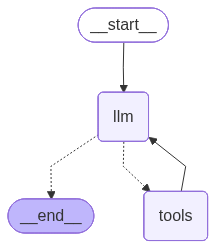

In [109]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))


In [110]:
result = app.invoke({
    "messages": [HumanMessage(content="what is the stock price of TCS.NS?")]
})

In [111]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (50stx6cjd)
 Call ID: 50stx6cjd
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2692.20.
================================== Ai Message ==================================

The current stock price of TCS.NS is ₹2692.20.


In [132]:
result = app.invoke({
    "messages": [HumanMessage(content="Give me the latest AI news count the length of response and multiply that response with 10.")]
})

In [133]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the latest AI news count the length of response and multiply that response with 10.
================================== Ai Message ==================================

I can provide you with the latest AI news and then perform the requested operations. However, to count the length of the response and multiply it by 10, I would need to follow these steps:

1. Search for the latest AI news.
2. Count the length of the response.
3. Multiply the length by 10.

Since the problem involves multiple steps including searching and then using the result to perform calculations, let's break it down:

First, I'll search for the latest AI news using Wikipedia:
Tool Calls:
  wikipedia (kdm5er3ck)
 Call ID: kdm5er3ck
  Args:
    query: latest AI news
================================= Tool Message =================================
Name: wikipedia

Page: Mistral AI
Summary: Mistral AI SAS (French: [mistʁal]) is a Fren

In [134]:
result = app.invoke({
    "messages": [HumanMessage(content="How did Trump's tariff policy impact the TCS.NS?")]
})

In [135]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How did Trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (9hpy880ma)
 Call ID: 9hpy880ma
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2692.20.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (1ndes7x52)
 Call ID: 1ndes7x52
  Args:
    query: Impact of Trump's tariff policy on TCS.NS
================================= Tool Message =================================
Name: wikipedia

No good Wikipedia Search Result was found
================================== Ai Message ==================================

Trump's tariff policy had a negative impact on the Indian IT sector, including TCS.NS. The tariffs imposed by the US on certain 